# Statistiques Tokens Types

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import random as rd
import datetime as dt
import pickle,glob,re,yaml
import numpy as np

In [4]:
repNom="/Users/gilles/pCloud Drive/FOD/GB/2015-Data/Samples/Verbes3/"
repMemoire="/Users/gilles/sDrive/Recherche/Boye/HDR/Memoire/"

In [5]:
listeTirages=glob.glob(repNom+"*-Tirage.pkl")
listeTirages

['/Users/gilles/pCloud Drive/FOD/GB/2015-Data/Samples/Verbes3/MGC-1000Ko-50-T1000000-F39896-Tirage.pkl',
 '/Users/gilles/pCloud Drive/FOD/GB/2015-Data/Samples/Verbes3/MGC-1000Ko-51-T1000000-F39749-Tirage.pkl',
 '/Users/gilles/pCloud Drive/FOD/GB/2015-Data/Samples/Verbes3/MGC-1000Ko-52-T1000000-F39883-Tirage.pkl',
 '/Users/gilles/pCloud Drive/FOD/GB/2015-Data/Samples/Verbes3/MGC-1000Ko-53-T1000000-F39771-Tirage.pkl',
 '/Users/gilles/pCloud Drive/FOD/GB/2015-Data/Samples/Verbes3/MGC-1000Ko-54-T1000000-F39832-Tirage.pkl',
 '/Users/gilles/pCloud Drive/FOD/GB/2015-Data/Samples/Verbes3/MGC-1000Ko-55-T1000000-F39745-Tirage.pkl',
 '/Users/gilles/pCloud Drive/FOD/GB/2015-Data/Samples/Verbes3/MGC-1000Ko-56-T1000000-F39808-Tirage.pkl',
 '/Users/gilles/pCloud Drive/FOD/GB/2015-Data/Samples/Verbes3/MGC-1000Ko-57-T1000000-F39791-Tirage.pkl',
 '/Users/gilles/pCloud Drive/FOD/GB/2015-Data/Samples/Verbes3/MGC-1000Ko-58-T1000000-F39773-Tirage.pkl',
 '/Users/gilles/pCloud Drive/FOD/GB/2015-Data/Samples/V

In [14]:
population={}
for tirage in listeTirages:
    m=re.search(r"-T(\d+)-F(\d+)-",tirage)
    if m:
        tokens=m.group(1)
        types=int(m.group(2))
        if tokens not in population:
            population[tokens]=[]
        population[tokens].append(types)
[(k, np.mean(v)) for k,v in population.items()]

[('1000000', 39800.3), ('100000', 14846.72), ('10000', 3630.91)]

## Calcul de la moyenne des types en fonction des tokens

In [8]:
def tiragesNom(nom):
    result=[tirage for tirage in listeTirages if nom in tirage]
    return result

In [26]:
compositionLongitudinale=[("1Ko",10),("10Ko",9),("100Ko",9),("1Mo",19)]
compositionLongitudinale=[("10Mo",20)]
compositionLongitudinale=[("10Ko",10),("100Ko",9),("1Mo",9)]
compositionLongitudinale=[("1000Ko",20)]
compositionLongitudinale=[("1000Ko",5),("10000Ko",10)]
compositionLongitudinale=[("1000Ko",32)]

In [27]:
def tiragesNom(nom):
    result=[tirage for tirage in listeTirages if nom in tirage]
    return result

In [34]:
def tireSerie(compositionLongitudinale):
    serieLongitudinale=[]
    for serie,nbSerie in compositionLongitudinale:
        for nom in rd.sample(tiragesNom(serie),nbSerie):
            m=re.match(r"^.*-%s-(\d{2})-T.*-F.*-Tirage.*"%serie,nom)
            if m:
    #            print m.group(1), nom
                serieLongitudinale.append(nom)
            else:
                print ("mauvais nom de fichier",nom)
    return serieLongitudinale

In [29]:
def lireLexique(tirage):
    return pd.read_pickle(tirage)

In [46]:
cumule=True
compositionLongitudinale=[("1000Ko",30)]
lNbTypes=[]
for i in range(10):
    serieLongitudinale=tireSerie(compositionLongitudinale)
    cumulLexique=lireLexique(serieLongitudinale[0])
    cumulLexique["tir1"]=0
    for nTirage,tirage in enumerate(serieLongitudinale):
        lexique=lireLexique(tirage)
        if cumule:
            cumulLexique["tir1"]=cumulLexique["tir1"]+lexique["tir1"]
        else:
            cumulLexique["tir1"]=lexique["tir1"]
        lexique1=cumulLexique[cumulLexique["tir1"]>0]
        nbTokens=lexique1["tir1"].sum()
        nbTypes=lexique1["tir1"].count()
    print ("(%d,%d),"%(nbTokens,nbTypes))
    lNbTypes.append(nbTypes)
np.mean(lNbTypes)

(30000000,70149),
(30000000,70109),
(30000000,70108),
(30000000,70166),
(30000000,70151),
(30000000,70170),
(30000000,70144),
(30000000,70106),
(30000000,70136),
(30000000,70179),


70141.8

## Graphe tokens types

In [5]:
tokensTypes={10000:3600, 30000:7500, 100000:14800, 300000:25200, 1000000:39800, 3000000:53700, 10000000:65100, 30000000:70100}

([<matplotlib.axis.XTick at 0x17b003010>,
 [Text(1000000, 0, '1M'), Text(10000000, 0, '10M'), Text(30000000, 0, '30M')])

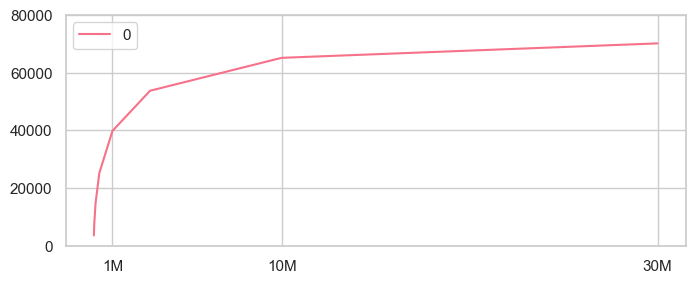

In [6]:
ax=pd.DataFrame.from_dict(tokensTypes,orient="index").plot(figsize=(8,3))
ax.set_xscale('linear')
ax.set_ylim(0,80000)
plt.xticks([1000000, 10000000, 30000000], labels=["1M","10M","30M"])

## Courbe Tokens Types

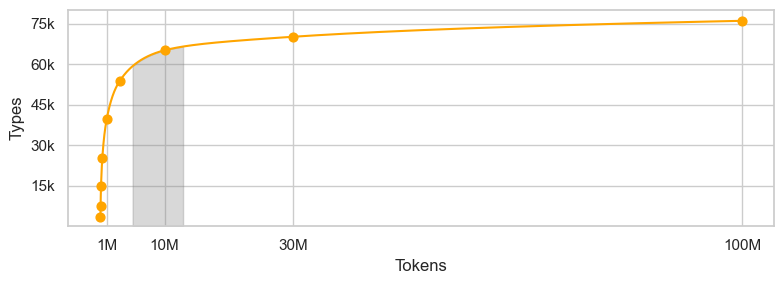

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator
import seaborn as sns

sns.set(style="ticks")
sns.set_style("whitegrid")
sns.set_palette("husl")


tokensTypes = {
    10000: 3600, 
    30000: 7500, 
    100000: 14800, 
    300000: 25200, 
    1000000: 39800, 
    3000000: 53700, 
    10000000: 65100, 
    30000000: 70100,
    100000000: 76000,
}

df = pd.DataFrame(list(tokensTypes.items()), columns=['Tokens', 'Types'])

# Interpolation PCHIP sur échelle Log(X) pour respecter l'écart entre les grandeurs
log_x = np.log10(df['Tokens'])
y = df['Types']

log_x_smooth = np.linspace(log_x.min(), log_x.max(), 500)
x_smooth = 10**log_x_smooth

pchip = PchipInterpolator(log_x, y)
y_smooth = pchip(log_x_smooth)
plt.figure(figsize=(8, 3))
plt.plot(x_smooth, y_smooth, label='types', color="orange")
plt.scatter(df['Tokens'], df['Types'], color='orange', zorder=5, s=40, label='Tableau')

x1, x2 = 5000000, 13000000
mask = (x_smooth >= x1) & (x_smooth <= x2)

plt.fill_between(
    x_smooth[mask], y_smooth[mask], 0,
    color="grey", alpha=0.3, clip_on=True
)



plt.xscale('linear')
plt.xlabel('Tokens')
plt.xticks([1000000, 10000000, 30000000,100000000], labels=["1M","10M","30M","100M"])
plt.yticks([15000, 30000, 45000,60000,75000], labels=["15k","30k","45k","60k","75k"])
plt.ylabel('Types')
plt.ylim(0,80000)
#plt.title('Courbe lissée monotone passant exactement par tous les points')
#plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend().remove()
plt.tight_layout()
plt.savefig(repMemoire+'figs/TokensTypes.png', dpi=300,bbox_inches="tight")

In [9]:
pchip(np.log10(13000000))

array(66523.87042824)

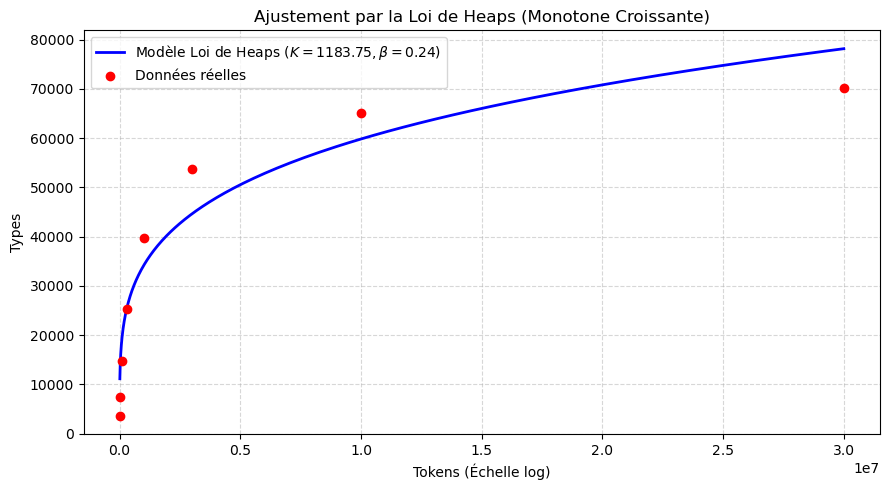

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. Données
tokensTypes = {
    10000: 3600, 
    30000: 7500, 
    100000: 14800, 
    300000: 25200, 
    1000000: 39800, 
    3000000: 53700, 
    10000000: 65100, 
    30000000: 70100
}

df = pd.DataFrame(list(tokensTypes.items()), columns=['Tokens', 'Types'])

# 2. Modèle de la Loi de Heaps : Types = K * (Tokens)^beta
def heaps_law(N, K, beta):
    return K * (N ** beta)

# Ajustement des paramètres K et beta sur vos données
popt, _ = curve_fit(heaps_law, df['Tokens'], df['Types'], p0=[10, 0.5])
K_opt, beta_opt = popt

# 3. Génération de la courbe lisse strictement croissante
x_smooth = np.logspace(np.log10(df['Tokens'].min()), np.log10(df['Tokens'].max()), 300)
y_smooth = heaps_law(x_smooth, K_opt, beta_opt)

# 4. Affichage
plt.figure(figsize=(9, 5))
plt.plot(x_smooth, y_smooth, label=f'Modèle Loi de Heaps ($K={K_opt:.2f}, \\beta={beta_opt:.2f}$)', color='blue', lw=2)
plt.scatter(df['Tokens'], df['Types'], color='red', zorder=5, label='Données réelles')

plt.xscale('linear')
plt.xlabel('Tokens (Échelle log)')
plt.ylabel('Types')
plt.title('Ajustement par la Loi de Heaps (Monotone Croissante)')
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()